In [264]:
%reset -f -s
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
from bspline_model import *
from workout import *



def fit_bayesian_spline(hr_data, knot_basis,  sample_size):
    """
    Factored model definition. 
    Returns the basis matrix (B), its derivative (dB_dt), and the MAP weights.
    """

    # 2. Compute Derivative Basis
    # We use gradient here to get the slope of the basis functions
    dB_dt = np.gradient(knot_basis, axis=0)

    # 3. Bayesian Model Definition
    with pm.Model() as model:
        # tau = pm.Exponential("tau", 0.002)
        # w = pm.GaussianRandomWalk("w", sigma=tau, shape=B.shape[1])
        w = pm.Normal("w", mu=130, sigma=40, shape=knot_basis.shape[1])
        mu = pm.Deterministic("mu", pm.math.dot(knot_basis, w))
        # Derivative/Punch at every time step
        accel = pm.Deterministic("accel", pm.math.dot(w, dB_dt.T))
        
        sigma = pm.HalfNormal("sigma", sigma=5)
        pm.StudentT("obs", nu=4, mu=mu, sigma=sigma, observed=hr_data)
        
        # Sampling 1000 draws to build the HDI
        chains = 2
        trace = pm.sample(int(sample_size / chains), tune=1000, chains=chains, target_accept=0.9, progressbar=False)
        
    return trace


workout_df = pd.DataFrame([
    ('polar_data/oo_dd_2025-12-24_18-32-17.CSV', standard_3x4.name, 130, 0),
    ('polar_data/oo_dd_2025-12-30_11-32-46.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-02_17-45-25.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-05_16-54-37.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-07_17-13-36.CSV', standard_3x4.name, 240, 0), 
    ('polar_data/oo_dd_2026-01-15_16-59-15.CSV', xtrainer_4x4.name, 0, 0),
    ('polar_data/oo_dd_2026-01-18_16-31-02.CSV', standard_3x4.name, 240, 0),
    ],
    columns=["file_path", "workout_config", "n_drop", "kernel_size"]).assign(
        session_name=lambda x: [Path(p).stem[6:16] for p in x.file_path],
        cache_path=lambda x: [Path(p).with_suffix(".nc") for p in x.file_path]
    )

knots_data = {
    "2025-12-24": np.array(list(sorted(
        set(range(0, 838, 40)) | {152, 162, 200, 210, 240, 256, 388, 660, 720}
        ))).reshape((-1, 1)),
    "2025-12-30": np.array(list(sorted(
        set(range(0, 854, 30)) | {126, 145, 700, 734, 747}
    ))).reshape((-1, 1)),
    "2026-01-02": np.array(list(sorted(
        set(range(0, 847, 40)) | {222, 242, 420, 440, 485, 527, 698, 726}
    ))).reshape((-1, 1)),
    "2026-01-05": np.array(list(sorted(
        set(range(0, 848, 40)) | {210, 225, 260, 419, 454, 505, 560, 700, 731}
    ))).reshape((-1, 1)),
    "2026-01-18": np.array(list(sorted(
        set(range(0, 866, 40)) | {210, 225, 250, 260, 470, 455, 490, 505, 560, 700, 727, 740}
    ))).reshape((-1, 1))
}

wc = standard_3x4
load_cache = False
sessions = []
for i, session_row in list(workout_df.loc[lambda x: x.workout_config == wc.name].iterrows()):
    
    # if session_row.session_name != "2026-01-18":
    #     continue
    
    session_df = pd.read_csv(session_row.file_path, skiprows=2).iloc[session_row.n_drop:, 1:3].assign(
        time_sec=lambda x: pd.to_timedelta(x.Time).dt.total_seconds() - session_row.n_drop
    )
    print(session_row.session_name)
    print(session_df.time_sec.shape[0])
    knot_generator = KnotGenerator(time=session_df.time_sec.values, degree=3)
    try:
        knots = knots_data[session_row.session_name]
    except KeyError:
        continue
    basis = knot_generator.custom(list(sorted(knots)))

    if load_cache and session_row.cache_path.is_file():
        trace = az.from_netcdf(session_row.cache_path)
    else:        
        trace = fit_bayesian_spline(session_df['HR (bpm)'].values, basis, 1000)
        trace.to_netcdf(session_row.cache_path)
    
    sessions.append(
        TreadmillAnalytic(
            time=session_df.time_sec.values, 
            hr=session_df['HR (bpm)'].values, 
            session_id=session_row.session_name, 
            config=wc, 
            trace=trace,
            load_cache=True, 
            cache_path=Path(session_row.cache_path))
    )
report = TreadmillReport(wc, sessions)

Initializing NUTS using jitter+adapt_diag...


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2025-12-24
838


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [w, sigma]
Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...


2025-12-30
855


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [w, sigma]
Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...


...

Multiprocess sampling (2 chains in 2 jobs)
NUTS: [w, sigma]
Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...


2026-01-05
848


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [w, sigma]
Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...


2026-01-07
849
2026-01-18
866


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [w, sigma]
Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning:

hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions



/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning:

hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions

/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning:

hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions



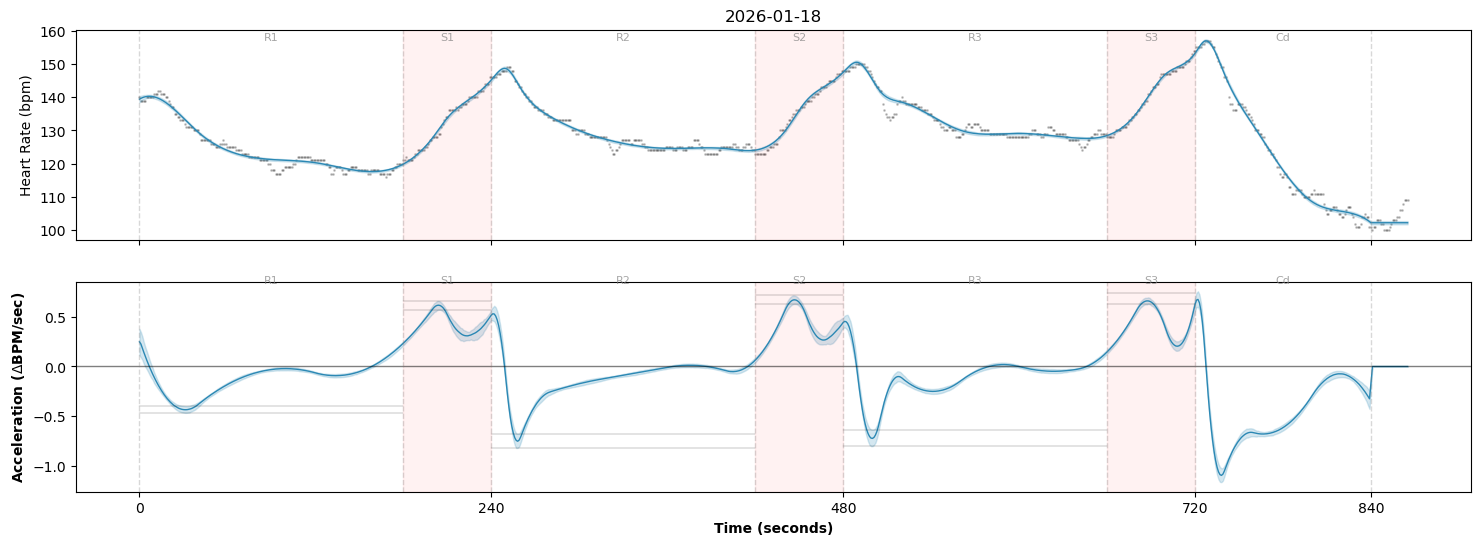

In [262]:

import plotly.express as px

import plotly.graph_objects as go

def add_custom_rug(fig, x_coords, label="Transitions", color="black"):
    """
    Adds a custom rug trace to an existing Plotly figure.
    """
    fig.add_trace(go.Scatter(
        x=x_coords,
        # We set Y to a constant (usually slightly below your min HR)
        y=[fig.data[0].y.max() - 5] * len(x_coords), 
        mode='markers',
        marker=dict(
            symbol='line-ns-open', # This creates the 'rug' tick shape
            size=16,               # Height of the rug tick
            line=dict(width=2, color=color)
        ),
        name=label,
        showlegend=True
    ))


# Plotting heart rate for all sessions at once
fig = px.scatter(session_df,  x="time_sec", y="HR (bpm)", render_mode="webgl", opacity=0.3
                 ) # 'webgl' makes it super fast for many points

hr_stats = MedianHdiSample.from_samples(report.sessions[0].post_mu, report.sessions[0].post_mu.shape[0])
fig2 = px.line(pd.DataFrame({"time_sec": report.sessions[0].time, "HR (bpm)": hr_stats.median}), x="time_sec", y="HR (bpm)")
fig2.update_traces(line=dict(color="firebrick", width=3))
fig.add_traces(fig2.data)
add_custom_rug(fig, knots.flatten())
fig.show()


fig, axes = plt.subplots(ncols=min(len(report.sessions), 1), nrows=2, figsize=(18, 6), sharex=True, sharey='row')
report.plot_fit_accel(fig, axes)

# B-Splines

/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning:

hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions

/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning:

hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions

/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning:

hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions

/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning:

hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions

/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning:


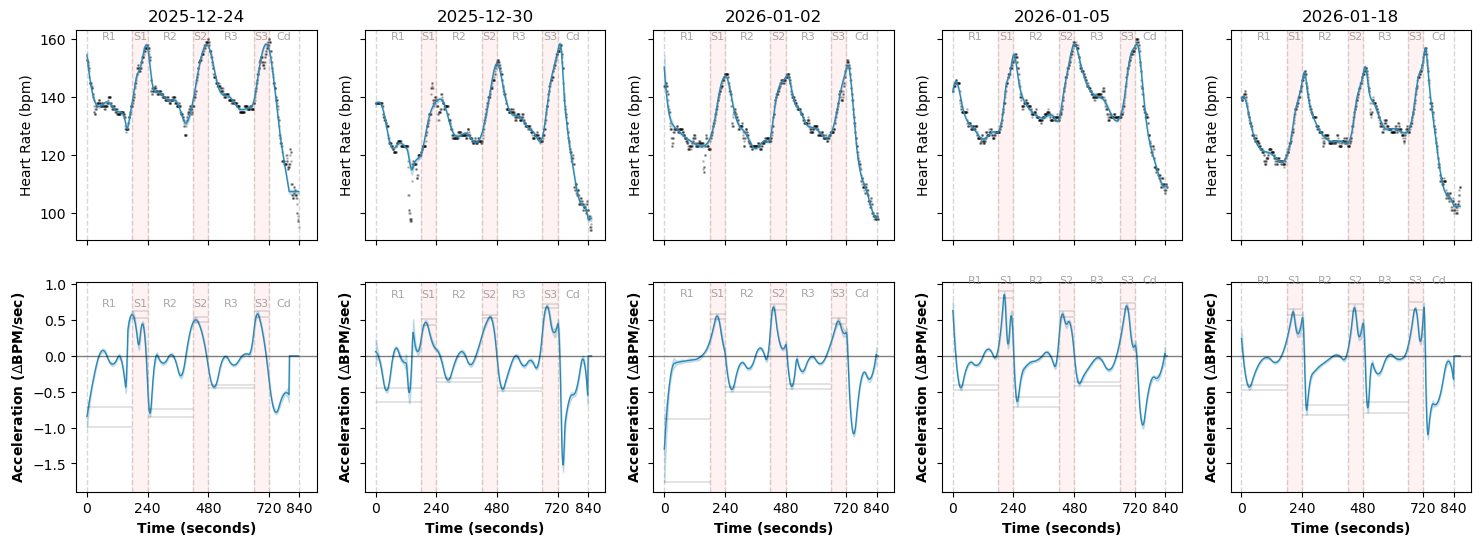

In [265]:
fig, axes = plt.subplots(ncols=min(len(report.sessions), 8), nrows=2, figsize=(18, 6), sharex=True, sharey='row')
report.plot_fit_accel(fig, axes)

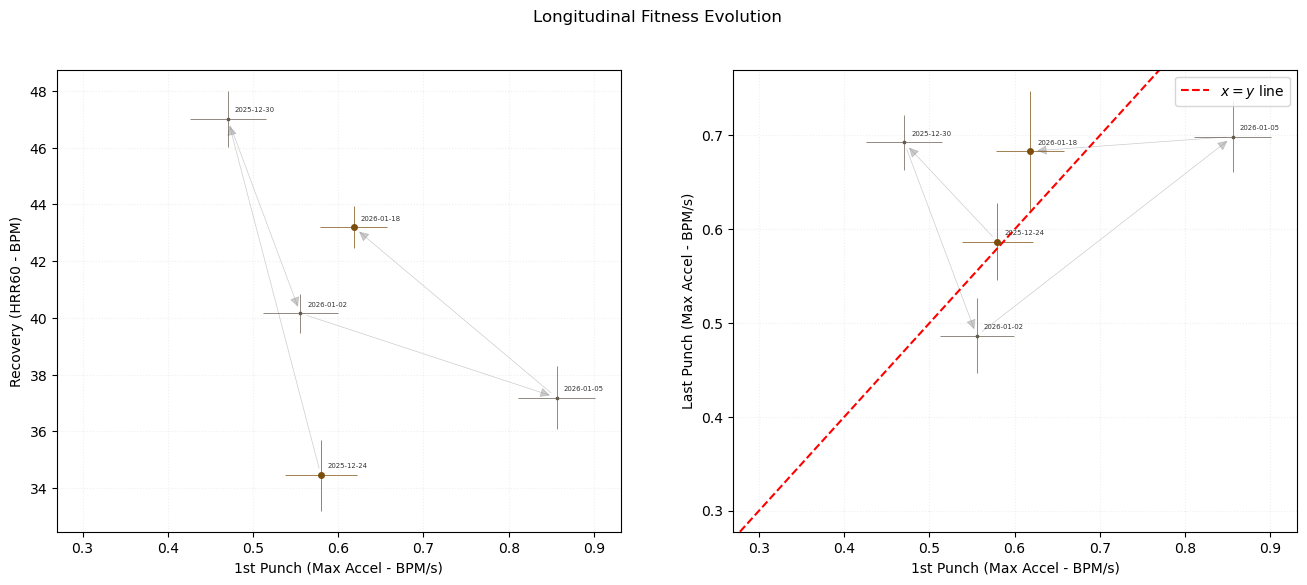

In [266]:
# report = TreadmillReport(standard_3x4, file_paths, False)
fig, ax_quad = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=False)
report.plot_trend_vector(fig, ax_quad[0], 'ph')
report.plot_trend_vector(fig, ax_quad[1], 'pp')
ax_quad[1].axline((0.3, 0.3), slope=1, color='r', linestyle='--', label='$x=y$ line'); ax_quad[1].legend()


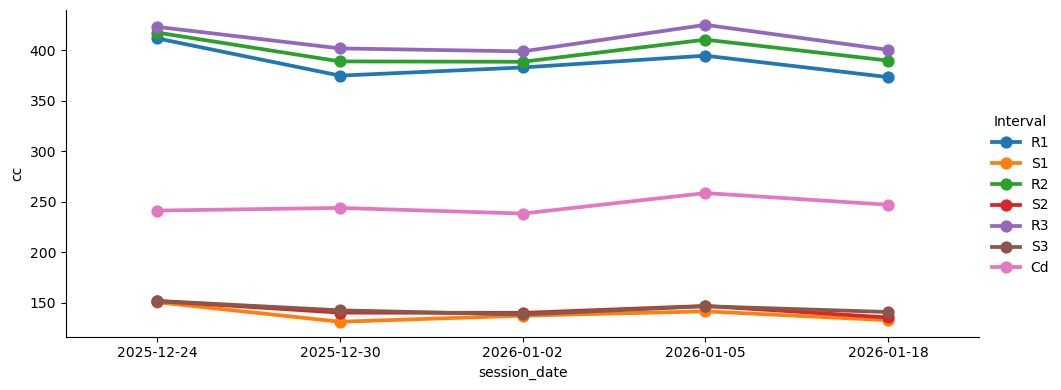

In [267]:
report.plot_cardiac_cost()